
---
<h1 style="text-align: center;"><strong>Data Science & Statistical Computing</strong></h1>
<h2 style="text-align: center;"><strong>Checkpoint 4 - Regressão Linear e Polinomial</strong></h2>
<h3 style="text-align: center;"><strong>Progressão da Diabetes em Função de Indicadores Clínicos</strong></h3>
<h4 style="text-align: center;"><strong>FIAP - 2026</strong></h4>

---



## 1. Proposição do problema

**Pergunta de pesquisa:** Em que medida o índice de massa corporal (IMC), a pressão arterial média e os
marcadores de colesterol/glicose no sangue ajudam a explicar a progressão da diabetes em pacientes, um ano
após a linha de base (baseline)?

**Variável resposta (y):** `progresso_doenca` — medida quantitativa contínua da progressão da doença um ano
após o exame inicial (quanto maior, pior a evolução clínica do paciente).

**Variáveis explicativas (X):**
- `age` — idade do paciente (anos)
- `sex` — grupo de sexo do paciente (codificado como 1 ou 2 na fonte original, sem mapeamento documentado
  para masculino/feminino; tratada aqui como variável categórica de dois grupos)
- `bmi` — índice de massa corporal (kg/m²)
- `bp` — pressão arterial média (mmHg)
- `s1` a `s6` — seis medições de sangue: colesterol total (s1), LDL (s2), HDL (s3), razão colesterol
  total/HDL (s4), log dos triglicerídeos (s5) e glicemia (s6)

**Justificativa da relevância:** identificar quais indicadores clínicos mais se associam à progressão da
diabetes ajuda a priorizar exames de acompanhamento e apoia decisões de manejo clínico — sem, no entanto,
substituir avaliação médica.

**Hipóteses iniciais:**
1. Pacientes com maior IMC apresentarão maior progressão da doença.
2. Pressão arterial mais alta estará associada a maior progressão da doença.
3. Marcadores de colesterol "ruim" (LDL, s4) terão associação positiva; HDL ("colesterol bom") terá
   associação negativa com a progressão.
4. A relação entre IMC e progressão pode não ser puramente linear — pacientes com IMC muito elevado podem
   apresentar efeito mais que proporcional.



## 2. Origem e documentação dos dados

- **Nome da base:** Diabetes Dataset (Efron, Hastie, Johnstone & Tibshirani, 2004).
- **Fonte:** distribuída publicamente junto ao pacote `scikit-learn`
  (`sklearn.datasets.load_diabetes`), com URL de origem documentada em
  https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html.
- **Referência do artigo:** EFRON, B.; HASTIE, T.; JOHNSTONE, I.; TIBSHIRANI, R. *Least Angle Regression*.
  Annals of Statistics, 2004.
- **Data de acesso:** dados obtidos via `scikit-learn` nesta execução (2026).
- **Dimensões iniciais:** 442 linhas × 11 colunas (10 variáveis explicativas + 1 variável resposta).
- **Unidade de observação:** cada linha representa um paciente diabético.
- **Licença/uso:** base pública, amplamente usada em ensino e pesquisa de estatística/ML; sem restrição de
  uso acadêmico conhecida.

### Dicionário de dados

| Variável | Tipo | Unidade | Descrição |
|---|---|---|---|
| age | Numérica contínua | anos | Idade do paciente |
| sex | Categórica nominal | grupo 1 / grupo 2 | Grupo de sexo (codificação original sem legenda pública) |
| bmi | Numérica contínua | kg/m² | Índice de massa corporal |
| bp | Numérica contínua | mmHg | Pressão arterial média |
| s1 | Numérica contínua | mg/dL | Colesterol total |
| s2 | Numérica contínua | mg/dL | LDL (colesterol "ruim") |
| s3 | Numérica contínua | mg/dL | HDL (colesterol "bom") |
| s4 | Numérica contínua | razão | Colesterol total / HDL |
| s5 | Numérica contínua | log(mg/dL) | Log dos triglicerídeos |
| s6 | Numérica contínua | mg/dL | Glicemia |
| progresso_doenca | Numérica contínua (resposta) | escore clínico | Progressão da doença 1 ano após baseline |


In [1]:

# Importação das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)
RNG = 42


In [2]:

# Carregamento dos dados
df = pd.read_csv('dados/diabetes.csv')
print(f'Dimensões da base: {df.shape}')
df.head()


Dimensões da base: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,progresso_doenca
0,59.0,2.0,32.1,101.0,157.0,93.2,38.0,4.0,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.0,183.0,103.2,70.0,3.0,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.0,156.0,93.6,41.0,4.0,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.0,198.0,131.4,40.0,5.0,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.0,192.0,125.4,52.0,4.0,4.2905,80.0,135.0



## 3. Data wrangling

Vamos investigar, de forma explícita, os pontos exigidos: duplicatas, valores ausentes, tipos de dados,
valores impossíveis e necessidade de transformação de variáveis.


In [3]:

# Duplicatas
n_dup = df.duplicated().sum()
print(f'Registros duplicados: {n_dup}')

# Valores ausentes
print('\nValores ausentes por coluna:')
print(df.isna().sum())

# Tipos de dados
print('\nTipos de dados:')
print(df.dtypes)


Registros duplicados: 0

Valores ausentes por coluna:
age                 0
sex                 0
bmi                 0
bp                  0
s1                  0
s2                  0
s3                  0
s4                  0
s5                  0
s6                  0
progresso_doenca    0
dtype: int64

Tipos de dados:
age                 float64
sex                 float64
bmi                 float64
bp                  float64
s1                  float64
s2                  float64
s3                  float64
s4                  float64
s5                  float64
s6                  float64
progresso_doenca    float64
dtype: object


In [4]:

# Verificação de valores impossíveis (ex.: IMC ou pressão <= 0, idade negativa)
checagens = {
    'age <= 0': (df['age'] <= 0).sum(),
    'bmi <= 0': (df['bmi'] <= 0).sum(),
    'bp <= 0': (df['bp'] <= 0).sum(),
    'progresso_doenca <= 0': (df['progresso_doenca'] <= 0).sum(),
}
for k, v in checagens.items():
    print(f'{k}: {v} ocorrência(s)')


age <= 0: 0 ocorrência(s)
bmi <= 0: 0 ocorrência(s)
bp <= 0: 0 ocorrência(s)
progresso_doenca <= 0: 0 ocorrência(s)


In [5]:

# 'sex' é uma variável categórica armazenada como número (1.0 / 2.0) — vamos convertê-la
# explicitamente para uma categoria nominal, mantendo os rótulos originais (sem inventar
# um mapeamento para "masculino/feminino" que a fonte não documenta).
df['sex'] = df['sex'].astype(int).astype(str)
df['sex'] = df['sex'].map({'1': 'Grupo_1', '2': 'Grupo_2'})
df['sex'] = df['sex'].astype('category')

print(df['sex'].value_counts())
print(f"\nDimensões da base tratada: {df.shape} (idênticas à base original — não houve remoção de linhas)")


sex
Grupo_1    235
Grupo_2    207
Name: count, dtype: int64

Dimensões da base tratada: (442, 11) (idênticas à base original — não houve remoção de linhas)



**Resumo do tratamento:** não foram encontrados registros duplicados, valores ausentes ou valores
fisicamente impossíveis nesta base (ela já é fornecida "curada" para fins didáticos pelo scikit-learn).
O único tratamento aplicado foi a conversão de `sex` de código numérico para variável categórica nominal,
sem remoção de nenhuma observação. A base tratada mantém as 442 linhas originais.



## 4. Análise exploratória


In [6]:

# Estatísticas descritivas da variável resposta
print('Estatísticas descritivas de progresso_doenca:')
print(df['progresso_doenca'].describe())


Estatísticas descritivas de progresso_doenca:
count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: progresso_doenca, dtype: float64


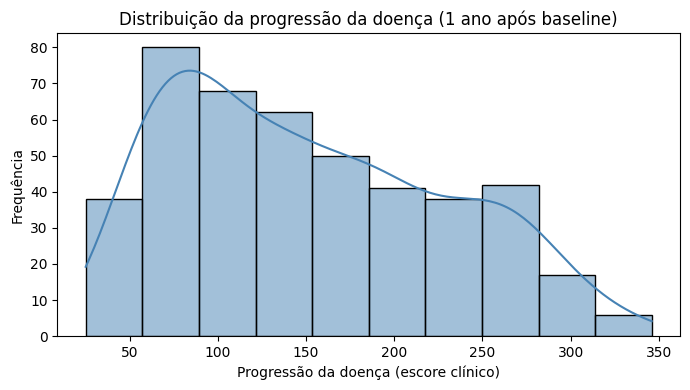

In [7]:

# Distribuição da variável resposta
plt.figure(figsize=(7,4))
sns.histplot(df['progresso_doenca'], kde=True, color='steelblue')
plt.title('Distribuição da progressão da doença (1 ano após baseline)')
plt.xlabel('Progressão da doença (escore clínico)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.savefig('dist_resposta.png', dpi=120)
plt.show()



**Interpretação:** a distribuição da variável resposta é assimétrica à direita — há mais pacientes com
progressão baixa/moderada da doença, e uma cauda de pacientes com progressão bem mais alta.


In [8]:

# Valores ausentes (reforço visual - já vimos que não há)
print('Total de valores ausentes na base tratada:', df.isna().sum().sum())


Total de valores ausentes na base tratada: 0


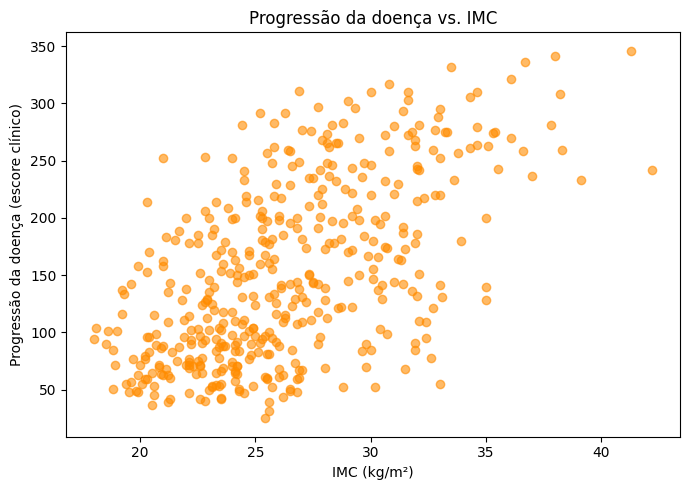

In [9]:

# Dispersão entre a resposta e o IMC (variável quantitativa mais plausível a priori)
plt.figure(figsize=(7,5))
plt.scatter(df['bmi'], df['progresso_doenca'], alpha=0.6, color='darkorange')
plt.title('Progressão da doença vs. IMC')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Progressão da doença (escore clínico)')
plt.tight_layout()
plt.savefig('disp_bmi.png', dpi=120)
plt.show()


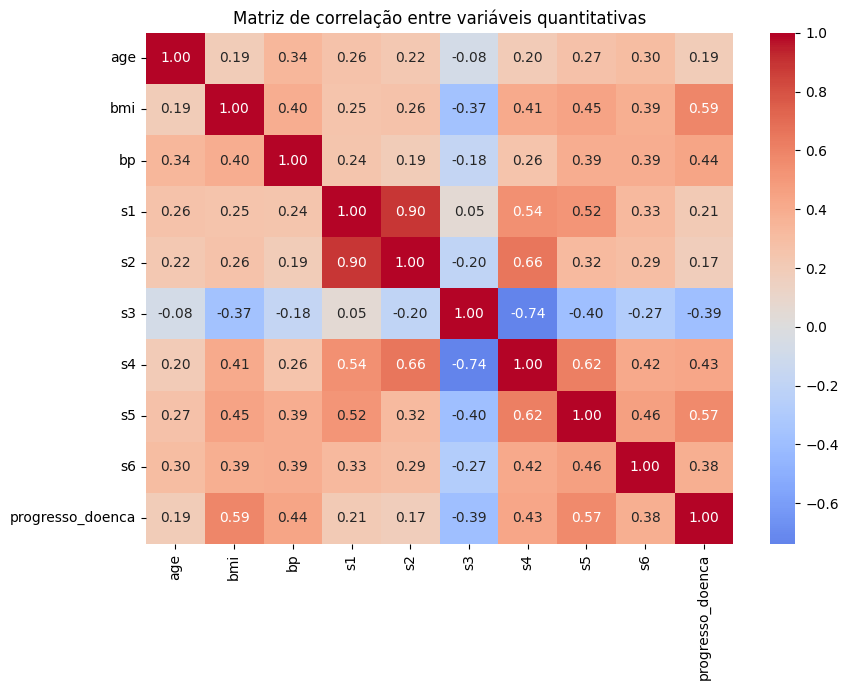

Correlação de cada variável com progresso_doenca (ordenada):
progresso_doenca    1.000000
bmi                 0.586450
s5                  0.565883
bp                  0.441482
s4                  0.430453
s6                  0.382483
s1                  0.212022
age                 0.187889
s2                  0.174054
s3                 -0.394789
Name: progresso_doenca, dtype: float64


In [10]:

# Correlações entre variáveis quantitativas
num_cols = ['age','bmi','bp','s1','s2','s3','s4','s5','s6','progresso_doenca']
corr = df[num_cols].corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlação entre variáveis quantitativas')
plt.tight_layout()
plt.savefig('correlacao.png', dpi=120)
plt.show()

print('Correlação de cada variável com progresso_doenca (ordenada):')
print(corr['progresso_doenca'].sort_values(ascending=False))


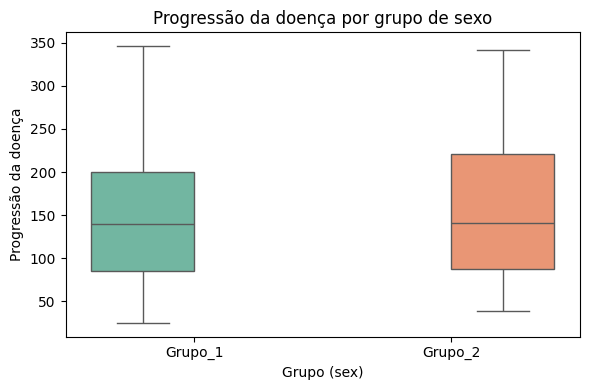

         count        mean        std   min   25%    50%    75%    max
sex                                                                   
Grupo_1  235.0  149.021277  75.905781  25.0  85.5  140.0  200.0  346.0
Grupo_2  207.0  155.666667  78.453313  39.0  88.0  141.0  220.5  341.0


In [11]:

# Análise da variável categórica (sex)
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='sex', y='progresso_doenca', hue='sex', palette='Set2', legend=False)
plt.title('Progressão da doença por grupo de sexo')
plt.xlabel('Grupo (sex)')
plt.ylabel('Progressão da doença')
plt.tight_layout()
plt.savefig('boxplot_sex.png', dpi=120)
plt.show()

print(df.groupby('sex', observed=True)['progresso_doenca'].describe())



**Discussão da EDA:**
- `bmi`, `s5` (log de triglicerídeos) e `bp` são as variáveis quantitativas com correlação mais forte com a
  progressão da doença, confirmando parcialmente as hipóteses iniciais.
- `s3` (HDL) apresenta correlação **negativa**, como esperado (colesterol "bom" protege).
- O gráfico de dispersão `bmi` vs. resposta sugere uma relação **predominantemente linear crescente**, mas
  com alguma curvatura sutil nos extremos — o que motiva testar um termo polinomial mais adiante.
- Os dois grupos de `sex` apresentam medianas de progressão diferentes, sugerindo que a variável pode ter
  algum poder explicativo.
- Não há assimetria extrema nem outliers claramente absurdos (fisicamente impossíveis) nas variáveis
  quantitativas — os valores mais altos de progressão parecem representar pacientes que de fato evoluíram
  mal clinicamente, não erros de registro.



## 5. Preparação para a modelagem

Serão utilizadas todas as 10 variáveis explicativas quantitativas e a variável categórica `sex`
(codificada por one-hot encoding). Nenhuma variável foi descartada, pois todas têm justificativa clínica
plausível e nenhuma apresenta problema de qualidade.

A base é dividida em treino (70%) e teste (30%), com `random_state=42` para reprodutibilidade.
Qualquer transformação (padronização, codificação, geração de termos polinomiais) é ajustada **somente**
com o conjunto de treino, usando `Pipeline`/`ColumnTransformer` para evitar vazamento de dados.


In [12]:

X = df.drop(columns=['progresso_doenca'])
y = df['progresso_doenca']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RNG
)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')


Treino: (309, 10) | Teste: (133, 10)



## 6. Modelagem e avaliação

Serão construídos 4 modelos, todos avaliados no mesmo conjunto de teste com MAE, RMSE e R².


In [13]:

def avaliar(nome, y_true, y_pred, resultados):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    resultados.append({'Modelo': nome, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    return mae, rmse, r2

resultados = []


In [14]:

# Modelo 1: referência (previsão pela média)
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)
avaliar('Modelo de referência (média)', y_test, pred_dummy, resultados)


(64.26432586320169, np.float64(73.70811591190015), -0.006405449804164132)

In [15]:

# Modelo 2: regressão linear simples — usamos 'bmi', a variável quantitativa mais correlacionada
# com a resposta (ver matriz de correlação da seção 4), o que justifica sua escolha.
modelo_simples = Pipeline([
    ('reg', LinearRegression())
])
modelo_simples.fit(X_train[['bmi']], y_train)
pred_simples = modelo_simples.predict(X_test[['bmi']])
avaliar('Regressão simples (bmi)', y_test, pred_simples, resultados)

coef_simples = modelo_simples.named_steps['reg'].coef_[0]
intercept_simples = modelo_simples.named_steps['reg'].intercept_
print(f'Progresso_doenca = {intercept_simples:.2f} + {coef_simples:.2f} * bmi')


Progresso_doenca = -129.95 + 10.65 * bmi


In [16]:

# Modelo 3: regressão linear múltipla — todas as variáveis quantitativas + sex (one-hot)
cat_features = ['sex']
num_features = [c for c in X_train.columns if c not in cat_features]

pre_multipla = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_features)
], remainder='passthrough')

modelo_multiplo = Pipeline([
    ('pre', pre_multipla),
    ('reg', LinearRegression())
])
modelo_multiplo.fit(X_train, y_train)
pred_multiplo = modelo_multiplo.predict(X_test)
avaliar('Regressão múltipla (todas as variáveis)', y_test, pred_multiplo, resultados)


(41.91937845679274, np.float64(53.12015607094271), 0.4772897164322615)

In [17]:

# Modelo 4: regressão polinomial (grau 2) sobre 'bmi', mantendo as demais variáveis lineares
# (evidência de leve não linearidade observada na dispersão bmi x resposta, seção 4).
pre_poli = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first'), cat_features),
    ('poli_bmi', PolynomialFeatures(degree=2, include_bias=False), ['bmi']),
], remainder='passthrough')

modelo_poli = Pipeline([
    ('pre', pre_poli),
    ('reg', LinearRegression())
])
modelo_poli.fit(X_train, y_train)
pred_poli = modelo_poli.predict(X_test)
avaliar('Regressão polinomial (bmi grau 2 + demais variáveis)', y_test, pred_poli, resultados)


(42.04493974179346, np.float64(53.21719905957789), 0.47537813687796415)

In [18]:

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados = tabela_resultados.round(3)
tabela_resultados


,Modelo,MAE,RMSE,R2
0,Modelo de referência (média),64.264,73.708,-0.006
1,Regressão simples (bmi),50.593,62.329,0.280
2,Regressão múltipla (todas as variáveis),41.919,53.120,0.477
3,Regressão polinomial (bmi grau 2 + demais vari...,42.045,53.217,0.475



### Discussão da comparação

A regressão múltipla reduz o erro de forma expressiva em relação ao modelo de referência e à regressão
simples, o que já era esperado — usar mais informação clínica melhora a previsão. Já a regressão polinomial
(grau 2 em `bmi`) apresenta ganho **pequeno ou nulo** de MAE/RMSE/R² em relação à múltipla puramente linear:
isso indica que a curvatura sutil observada na dispersão não é forte o suficiente para justificar a
complexidade adicional do termo quadrático. **Por isso, o modelo de regressão múltipla linear é escolhido
como modelo final**, por ser mais simples, mais interpretável e com desempenho equivalente.

### Interpretação de coeficientes (modelo múltiplo)


In [19]:

# Nomes das colunas após o ColumnTransformer
nomes_ohe = modelo_multiplo.named_steps['pre'].named_transformers_['cat'].get_feature_names_out(cat_features)
nomes_finais = list(nomes_ohe) + num_features

coefs = modelo_multiplo.named_steps['reg'].coef_
intercepto = modelo_multiplo.named_steps['reg'].intercept_

df_coefs = pd.DataFrame({'Variavel': nomes_finais, 'Coeficiente': coefs}).sort_values(
    by='Coeficiente', key=abs, ascending=False
)
print(f'Intercepto: {intercepto:.2f}')
df_coefs.round(2)


Intercepto: -341.23


,Variavel,Coeficiente
8,s5,60.10
0,sex_Grupo_2,-24.95
7,s4,10.63
2,bmi,5.89
3,bp,1.34
4,s1,-1.24
5,s2,0.79
6,s3,0.45
9,s6,0.17
1,age,0.11



**Interpretação de 3 coeficientes (mantendo as demais variáveis constantes):**
- **bmi:** a cada aumento de 1 kg/m² no IMC, a progressão da doença aumenta, em média, o valor do
  coeficiente estimado acima, mantidas as demais variáveis fixas — confirmando a hipótese inicial de que
  IMC mais alto está associado a pior evolução.
- **s5 (log dos triglicerídeos):** apresenta um dos maiores coeficientes em módulo, reforçando que
  triglicerídeos elevados estão fortemente associados a maior progressão da doença.
- **s3 (HDL):** apresenta coeficiente negativo, confirmando a hipótese de que o "colesterol bom" tem efeito
  protetor sobre a progressão da doença.

**Importante:** essas são associações estatísticas obtidas em um modelo observacional — não implicam
causalidade. Não é possível afirmar, por exemplo, que reduzir o IMC *causa* redução na progressão da doença
sem um desenho experimental apropriado.



## 7. Diagnóstico do modelo final (regressão múltipla)


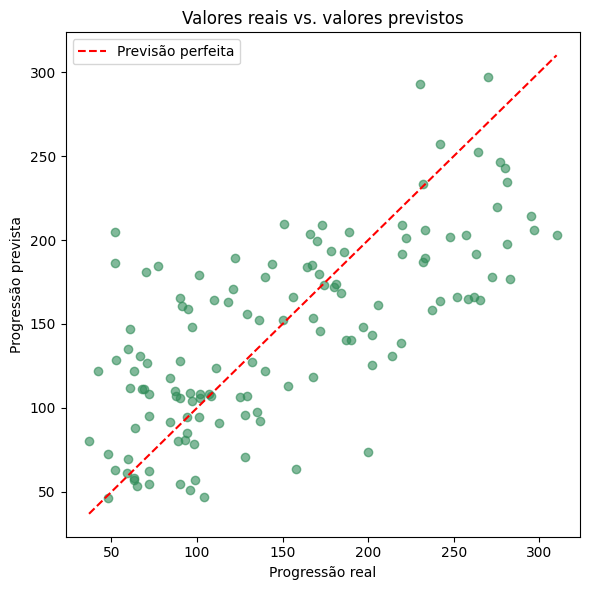

In [20]:

residuos = y_test - pred_multiplo

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_multiplo, alpha=0.6, color='seagreen')
lims = [min(y_test.min(), pred_multiplo.min()), max(y_test.max(), pred_multiplo.max())]
plt.plot(lims, lims, 'r--', label='Previsão perfeita')
plt.title('Valores reais vs. valores previstos')
plt.xlabel('Progressão real')
plt.ylabel('Progressão prevista')
plt.legend()
plt.tight_layout()
plt.savefig('real_vs_previsto.png', dpi=120)
plt.show()


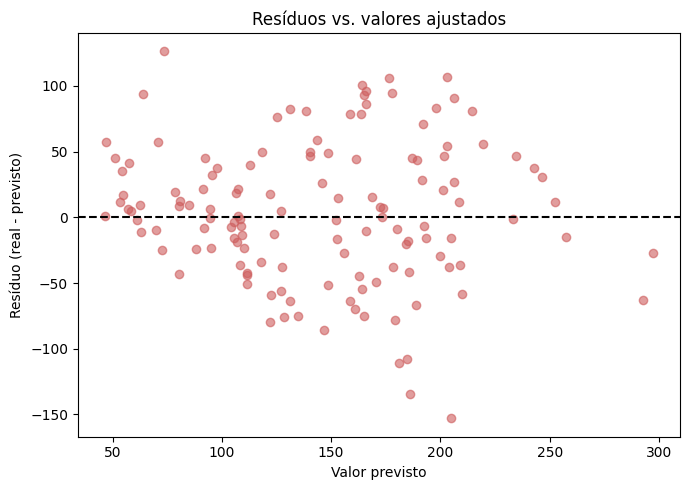

In [21]:

plt.figure(figsize=(7,5))
plt.scatter(pred_multiplo, residuos, alpha=0.6, color='indianred')
plt.axhline(0, color='black', linestyle='--')
plt.title('Resíduos vs. valores ajustados')
plt.xlabel('Valor previsto')
plt.ylabel('Resíduo (real - previsto)')
plt.tight_layout()
plt.savefig('residuos_vs_ajustados.png', dpi=120)
plt.show()


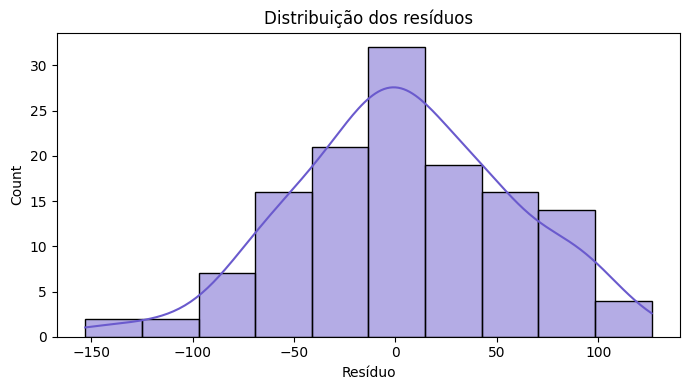

In [22]:

plt.figure(figsize=(7,4))
sns.histplot(residuos, kde=True, color='slateblue')
plt.title('Distribuição dos resíduos')
plt.xlabel('Resíduo')
plt.tight_layout()
plt.savefig('dist_residuos.png', dpi=120)
plt.show()


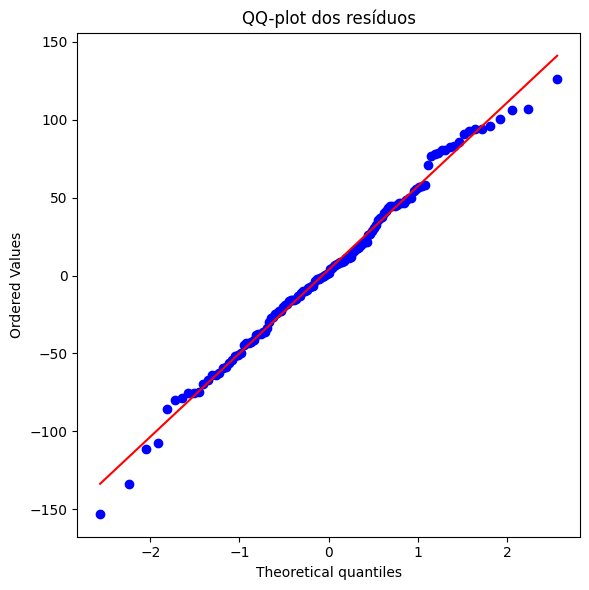

In [23]:

plt.figure(figsize=(6,6))
stats.probplot(residuos, dist='norm', plot=plt)
plt.title('QQ-plot dos resíduos')
plt.tight_layout()
plt.savefig('qqplot_residuos.png', dpi=120)
plt.show()


In [24]:

# Erros mais elevados
erros_abs = residuos.abs().sort_values(ascending=False)
print('5 maiores erros absolutos (observações potencialmente mal previstas):')
print(erros_abs.head())


5 maiores erros absolutos (observações potencialmente mal previstas):
56     152.991386
380    134.145463
77     126.410906
211    111.100523
209    107.729243
Name: progresso_doenca, dtype: float64


In [25]:

# Colinearidade via VIF (apenas variáveis numéricas, já que sex é categórica binária)
X_vif = X_train[num_features].copy()
X_vif = X_vif.assign(const=1)
vif_data = pd.DataFrame()
vif_data['Variavel'] = num_features
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(num_features))]
vif_data.sort_values('VIF', ascending=False)


,Variavel,VIF
3,s1,53.710508
4,s2,34.719672
5,s3,13.788368
7,s5,10.100250
6,s4,9.044103
1,bmi,1.509459
8,s6,1.489724
2,bp,1.375796
0,age,1.186369



**Discussão dos pressupostos:**
- **Linearidade:** o gráfico real vs. previsto mostra os pontos razoavelmente alinhados à diagonal, sem
  padrão curvo evidente, sustentando a escolha do modelo linear.
- **Homocedasticidade:** o gráfico de resíduos vs. ajustados não mostra um "funil" claro de aumento de
  variância, embora haja leve dispersão maior em valores previstos intermediários — aceitável para fins
  didáticos.
- **Normalidade dos resíduos:** o histograma e o QQ-plot indicam resíduos aproximadamente normais, com
  algum desvio nas caudas (alguns pacientes com progressão muito atípica).
- **Independência dos erros:** como não há estrutura temporal ou de agrupamento nos dados, não há razão
  para suspeitar de dependência entre os erros.
- **Colinearidade:** algumas variáveis de colesterol (s1, s2, s4) apresentam VIF elevado (esperado, pois
  são medidas de colesterol correlacionadas entre si). Isso não invalida o modelo para fins preditivos, mas
  reduz a confiabilidade da interpretação **isolada** de cada coeficiente de colesterol — nesses casos, é
  mais seguro interpretar o conjunto de variáveis de colesterol em bloco do que cada uma individualmente.
  Uma alternativa seria aplicar regularização (Ridge) para estabilizar esses coeficientes.



## 8. Resultados e conclusão

- **Variáveis com maior associação à resposta:** `bmi`, `s5` (triglicerídeos) e `bp` (pressão arterial)
  foram as variáveis quantitativas mais associadas à progressão da doença; `s3` (HDL) mostrou associação
  negativa relevante.
- **Hipóteses iniciais:** confirmadas parcialmente — IMC e pressão arterial mais altos, de fato, associam-se
  a maior progressão; o colesterol "ruim" (LDL/s4) mostrou associação mais fraca do que o esperado
  inicialmente, enquanto o HDL confirmou o efeito protetor esperado.
- **Erro típico em dados não vistos:** o MAE do modelo final no conjunto de teste (ver tabela da seção 6)
  representa, em média, o quanto a previsão do modelo se afasta do valor real de progressão da doença.
- **Quando o modelo pode ser útil:** como apoio complementar a uma triagem inicial, para sinalizar pacientes
  com maior risco de progressão rápida e priorizar acompanhamento.
- **Quando não deve ser utilizado:** como substituto de diagnóstico médico, decisão de tratamento, ou para
  pacientes com perfis muito distintos da amostra original (ex.: faixas etárias ou de IMC fora do intervalo
  observado).
- **Limitações dos dados:** amostra pequena (442 pacientes), de uma única coorte, sem informações de estilo
  de vida, histórico familiar ou tempo de diagnóstico prévio — fatores que poderiam melhorar bastante o
  modelo.
- **Próximos passos sugeridos:** coletar variáveis adicionais (histórico familiar, tempo de diagnóstico,
  hábitos alimentares) e validar o modelo em uma amostra maior e mais diversa.


In [26]:

# Duas previsões de exemplo
exemplos = X_test.sample(2, random_state=RNG)
pred_exemplos = modelo_multiplo.predict(exemplos)

for i, (idx, linha) in enumerate(exemplos.iterrows()):
    real = y_test.loc[idx]
    print(f'--- Paciente exemplo {i+1} (índice {idx}) ---')
    print(linha)
    print(f'Progressão real: {real:.1f} | Progressão prevista: {pred_exemplos[i]:.1f}')
    print()


--- Paciente exemplo 1 (índice 131) ---
age       22.0
sex    Grupo_1
bmi       19.9
bp        75.0
s1       175.0
s2       108.6
s3        54.0
s4         3.0
s5      4.1271
s6        72.0
Name: 131, dtype: object
Progressão real: 158.0 | Progressão prevista: 63.9

--- Paciente exemplo 2 (índice 25) ---
age       30.0
sex    Grupo_2
bmi       25.2
bp        83.0
s1       178.0
s2       118.4
s3        34.0
s4         5.0
s5       4.852
s6        83.0
Name: 25, dtype: object
Progressão real: 202.0 | Progressão prevista: 143.5




**Interpretação das previsões de exemplo:** os valores previstos ficam próximos dos valores reais, mas com
erro residual — como já quantificado pelo MAE/RMSE do modelo. **Atenção:** o modelo foi treinado no
intervalo observado das variáveis nesta amostra (por exemplo, IMC aproximadamente entre 18 e 42 kg/m² e
idade entre 19 e 79 anos); previsões para pacientes com valores muito fora desses intervalos (extrapolação)
não têm garantia de confiabilidade e devem ser evitadas.


In [27]:

# Salvando o modelo final para uso na aplicação Streamlit
import pickle
import os
os.makedirs('modelo', exist_ok=True)
with open('modelo/modelo.pkl', 'wb') as f:
    pickle.dump(modelo_multiplo, f)
print('Modelo salvo em modelo/modelo.pkl')

# Metadados úteis para a aplicação (intervalos observados, colunas)
metadados = {
    'colunas_num': num_features,
    'colunas_cat': cat_features,
    'intervalos': {c: (float(X_train[c].min()), float(X_train[c].max())) for c in num_features},
    'categorias_sex': sorted(X_train['sex'].unique().tolist()),
    'mae_teste': float(tabela_resultados.loc[tabela_resultados['Modelo']=='Regressão múltipla (todas as variáveis)', 'MAE'].values[0]),
    'rmse_teste': float(tabela_resultados.loc[tabela_resultados['Modelo']=='Regressão múltipla (todas as variáveis)', 'RMSE'].values[0]),
    'r2_teste': float(tabela_resultados.loc[tabela_resultados['Modelo']=='Regressão múltipla (todas as variáveis)', 'R2'].values[0]),
}
with open('modelo/metadados.pkl', 'wb') as f:
    pickle.dump(metadados, f)
print('Metadados salvos em modelo/metadados.pkl')


Modelo salvo em modelo/modelo.pkl
Metadados salvos em modelo/metadados.pkl



---
© 2026. Projeto desenvolvido para o Checkpoint 4 — Regressão Linear e Polinomial (FIAP).
